# Intent Classifier 

## Data Loading

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('intent_data.csv')

In [4]:
df.head()

,text,intent
0,Explain my report,report_query
1,Can you explain my medical report,report_query
2,Help me understand my report,report_query
3,What does my diagnosis mean,report_query
4,Can you tell me what my report says,report_query


In [5]:
df.intent.value_counts()

intent
report_query               30
medical_term_query         30
medical_knowledge_query    30
emotional_support          30
Name: count, dtype: int64

## Text Preprocessing

In [8]:
data = df.copy()

In [10]:
import re

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

data['text'] = df['text'].apply(preprocess)
data.head()

,text,intent
0,explain my report,report_query
1,can you explain my medical report,report_query
2,help me understand my report,report_query
3,what does my diagnosis mean,report_query
4,can you tell me what my report says,report_query


## Train Test Split

In [12]:
from sklearn.model_selection import train_test_split

X = data['text']
y = data['intent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

80% training
20% testing

## TF-IDF + SVM Pipeline

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        max_features=3000
    )),
    ("clf", LinearSVC())
])

In [14]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## Evaluation of the Model

In [15]:
from sklearn.metrics import classification_report

predictions = pipeline.predict(X_test)

print(classification_report(y_test, predictions))

                         precision    recall  f1-score   support

      emotional_support       1.00      0.83      0.91         6
medical_knowledge_query       0.71      0.83      0.77         6
     medical_term_query       0.80      0.67      0.73         6
           report_query       0.86      1.00      0.92         6

               accuracy                           0.83        24
              macro avg       0.84      0.83      0.83        24
           weighted avg       0.84      0.83      0.83        24



F1-score (Best Overall)
- balances false positives and false negatives
- works well with multiple classes
- widely used for NLP classification tasks

In [24]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, predictions, average="macro")
print("Macro F1 Score:", f1)

Macro F1 Score: 0.8321678321678323


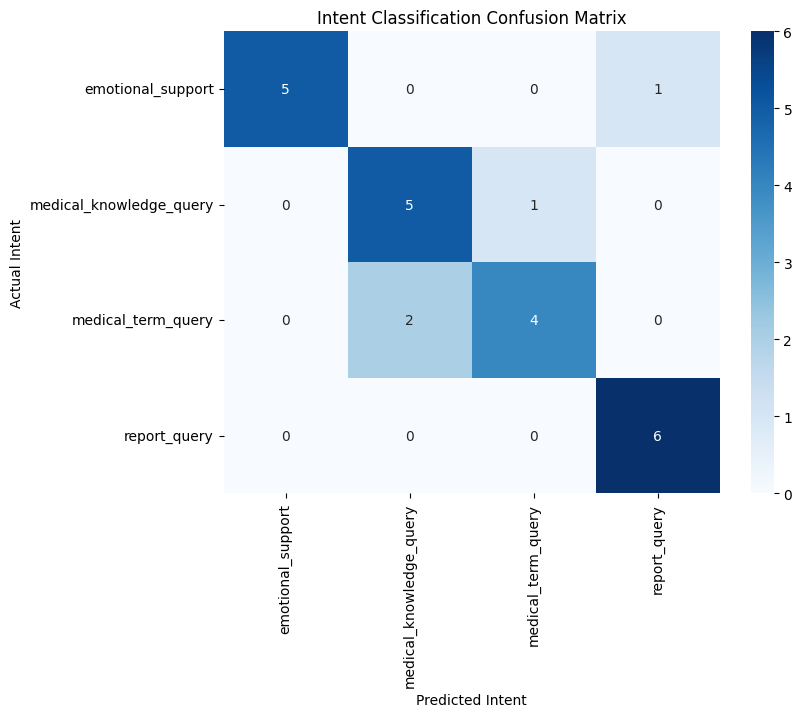

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get confusion matrix
cm = confusion_matrix(y_test, predictions, labels=pipeline.classes_)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=pipeline.classes_,
    yticklabels=pipeline.classes_
)

plt.xlabel("Predicted Intent")
plt.ylabel("Actual Intent")
plt.title("Intent Classification Confusion Matrix")
plt.show()

## Test with Custom Messages

In [17]:
test_messages = [
    "What does metasis mean?",
    "Explain my report",
    "What treatments are available for cancer?",
    "I'm really scared about my diagnosis"
]

for msg in test_messages:
    intent = pipeline.predict([msg])[0]
    print(msg, "->", intent)

What does metasis mean? -> medical_term_query
Explain my report -> report_query
What treatments are available for cancer? -> medical_knowledge_query
I'm really scared about my diagnosis -> emotional_support


## Saving the Model

In [58]:
import joblib

joblib.dump(pipeline, "intent_classifier.pkl")

['intent_classifier.pkl']

## Testing Loading the model

In [59]:
import joblib

model = joblib.load("intent_classifier.pkl")

def detect_intent(message):
    return model.predict([message])[0]

In [62]:
intent = detect_intent("what does metasis mean?")
print(intent)

medical_term_query


In [ ]:
intent = detect_intent("what is stage II cancer, I feel very scared about my diagnosis,")
print(intent)

emotional_support


## Visualizations

In [53]:
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=3000)

X_vect = vectorizer.fit_transform(X)

In [ ]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# Dimensionality reduction
svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(X_vect)

In [47]:
print(svd.explained_variance_ratio_)
print(sum(svd.explained_variance_ratio_))

[0.02080355 0.03406764]
0.054871190163918164


2026-03-17 13:51:57.108986: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/asish-jose/AI-ML/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


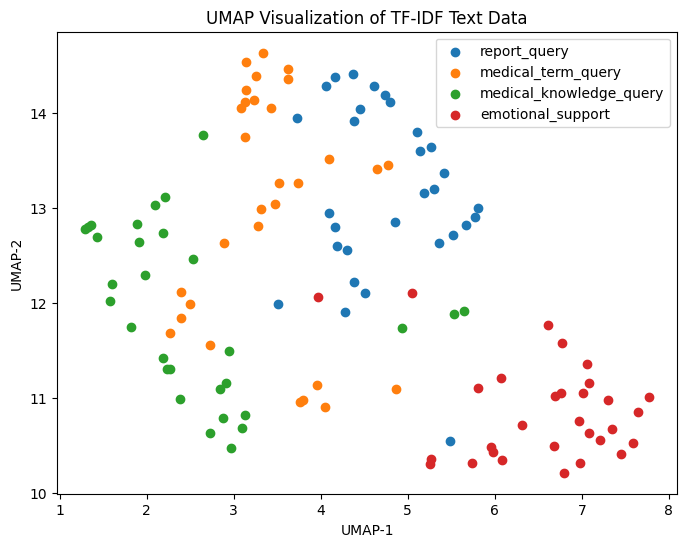

In [49]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

# Reduce TF-IDF vectors to 2D
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

X_umap = reducer.fit_transform(X_vect)

# Plot
plt.figure(figsize=(8,6))

labels = y.unique()

for label in labels:
    idx = (y == label)
    plt.scatter(
        X_umap[idx,0],
        X_umap[idx,1],
        label=label
    )

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP Visualization of TF-IDF Text Data")
plt.legend()
plt.show()